# Exploratory Data Analysis

This part analyses cleaned textual sentiment dataset. The analysis is on data quality, emotion-class balance, text-length distributions, relationships between Nature and Type, and potential biases or failure modes.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

data_path = Path("data/clean_data.csv")

df = pd.read_csv(data_path)

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (14133, 5)

Columns:
['Module Scheme Name', 'Nature', 'Description', 'Character Count', 'Type']


,Module Scheme Name,Nature,Description,Character Count,Type
0,Payment,Payment/TER Charges related Query,open att file,13,Enquiry
1,Deficiency,Deficiency related Query,Working Email,13,Grievance
2,Payment,Payment Updation Issue,Payment issue,13,Grievance
3,Payment,Payment Updation Issue,Payment issue,13,Required Support
4,DSC Utility,DSC Connection Issue,PLZ DO NEEDFUL,14,Required Support


## 1. Dataset Overview and Data Quality

For the audit, this part examines the dataset structure, data types, missing values, and duplicate observations.

In [15]:
print("Dataset information:")
df.info()

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nNumber of duplicate observations:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe(include="all"))

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Module Scheme Name  14133 non-null  str  
 1   Nature              14133 non-null  str  
 2   Description         14133 non-null  str  
 3   Character Count     14133 non-null  int64
 4   Type                14133 non-null  str  
dtypes: int64(1), str(4)
memory usage: 552.2 KB

Missing values by column:
Module Scheme Name    0
Nature                0
Description           0
Character Count       0
Type                  0
dtype: int64

Number of duplicate observations:
3564

Summary statistics:


,Module Scheme Name,Nature,Description,Character Count,Type
count,14133,14133,14133,14133.000000,14133
unique,10,42,10531,NaN,7
top,Other,Other,"Earlier (i.e. year 2009) the diploma programs of EEE, ECE, CE, and ME are affiliated with the STATE BOARD OF TECHNICAL EDUCATION AND TRAINING Hyde...",NaN,Grievance
freq,3340,4661,140,NaN,6841
mean,NaN,NaN,NaN,368.462039,NaN
std,NaN,NaN,NaN,230.434439,NaN
min,NaN,NaN,NaN,13.000000,NaN
25%,NaN,NaN,NaN,189.000000,NaN
50%,NaN,NaN,NaN,321.000000,NaN
75%,NaN,NaN,NaN,493.000000,NaN


## 2. Distribution of Emotion Classes

The target variable, `Type`, has 7 emotion classes. We will identify class imbalance that could affect model training and evaluation.

,Emotion,Count,Percentage
0,Grievance,6841,48.40
1,Required Support,2320,16.42
2,Willing to Support,1320,9.34
3,Enquiry,1243,8.80
4,Suggestion,1056,7.47
5,Appreciation,770,5.45
6,Complaint,583,4.13


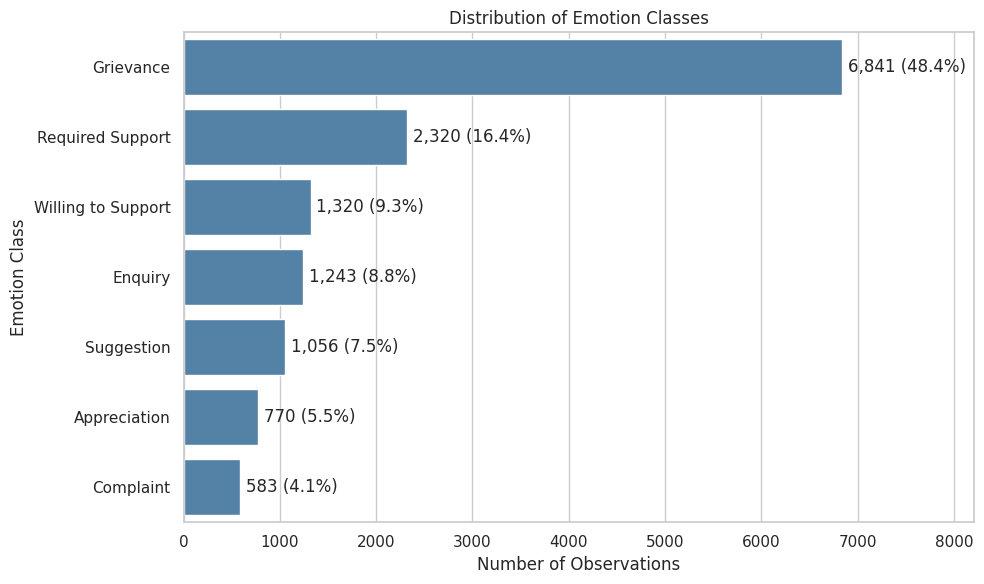

In [16]:
class_counts = df["Type"].value_counts()

class_summary = pd.DataFrame({
    "Emotion": class_counts.index,
    "Count": class_counts.values,
    "Percentage": (class_counts.values / len(df) * 100).round(2)
})

display(class_summary)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=class_summary,
    x="Count",
    y="Emotion",
    color="steelblue"
)

for i, row in class_summary.iterrows():
    ax.text(
        row["Count"] + 60,
        i,
        f'{row["Count"]:,} ({row["Percentage"]:.1f}%)',
        va="center"
    )

plt.title("Distribution of Emotion Classes")
plt.xlabel("Number of Observations")
plt.ylabel("Emotion Class")
plt.xlim(0, class_summary["Count"].max() * 1.20)
plt.tight_layout()
plt.show()

The dataset is imbalanced. Grievance which is like an unfair treatment or and injustice that gives someone a valid reason to complain, is the largest class ( 48.4% of all observations). Complaint is the smallest class at 4.1%. Almost half of the observations belong to one class (Grievance), accuracy alone may give a wrong evaluation of the model. Macro F1 and per-class precision and recall can also be important evaluation metrics.

## 3. Distribution of Description Lengths

The character count is what measures the length of each submission description. We will determine how much text the neural network will need to process.

,Character Count
count,14133.000000
mean,368.462039
std,230.434439
min,13.000000
25%,189.000000
50%,321.000000
75%,493.000000
max,1006.000000


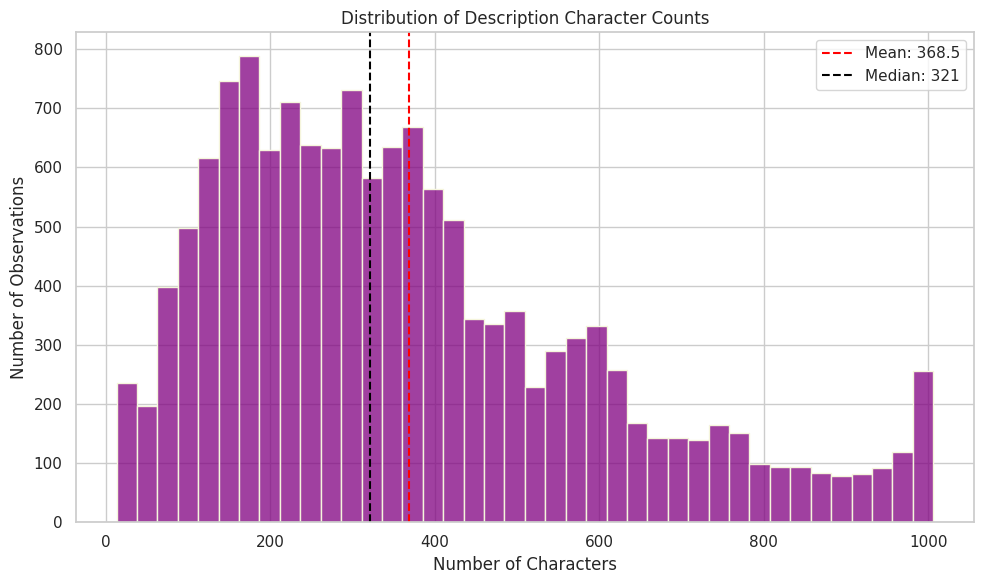

In [17]:
character_summary = df["Character Count"].describe()

display(character_summary.to_frame(name="Character Count"))

mean_length = df["Character Count"].mean()
median_length = df["Character Count"].median()

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Character Count",
    bins=40,
    color="purple",
    edgecolor="beige"
)

plt.axvline(
    mean_length,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_length:.1f}"
)

plt.axvline(
    median_length,
    color="black",
    linestyle="--",
    label=f"Median: {median_length:.0f}"
)

plt.title("Distribution of Description Character Counts")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Observations")
plt.legend()
plt.tight_layout()
plt.show()

The description lengths go from 13 to 1,006 characters. The median has 321 characters and ~368 characters. The mean is higher than the median so, the distribution is right-skewed: most descriptions are moderate in length, but some are longer. The concentration of observations around 1,000 characters may indicate a submission-length limit or truncated descriptions and should be considered a possible data artifact.

## 4. Distribution of Description Word Counts

Word count will provide a more useful estimate of the sequence lengths that the text-classification model will process.

,Word Count
count,14133.000000
mean,60.537961
std,37.246717
min,2.000000
25%,31.000000
50%,53.000000
75%,81.000000
max,182.000000


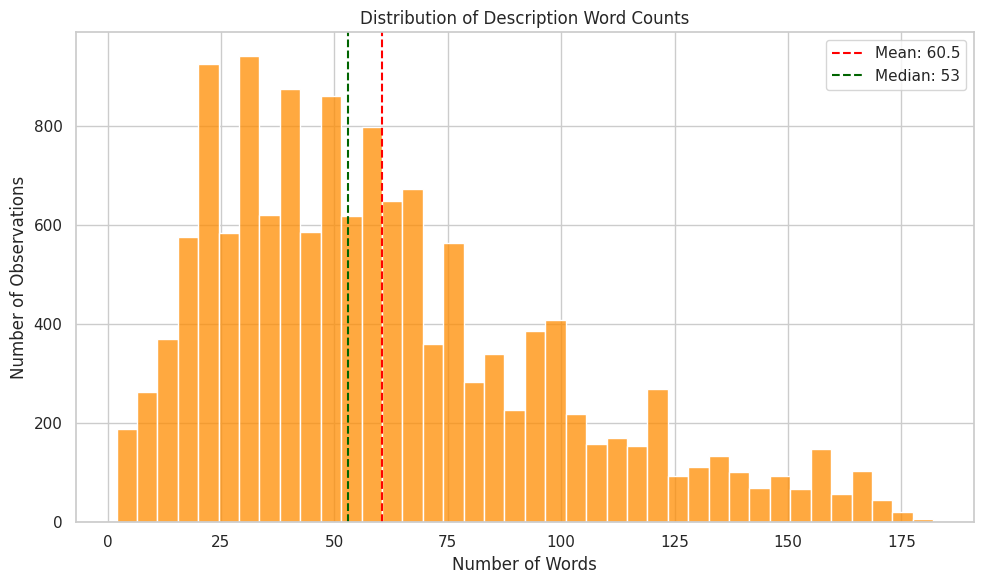

In [18]:
# Create a temporary word-count variable for EDA
df["Word Count"] = df["Description"].astype(str).str.split().str.len()

word_summary = df["Word Count"].describe()
display(word_summary.to_frame(name="Word Count"))

mean_words = df["Word Count"].mean()
median_words = df["Word Count"].median()

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Word Count",
    bins=40,
    color="darkorange",
    edgecolor="white"
)

plt.axvline(
    mean_words,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_words:.1f}"
)

plt.axvline(
    median_words,
    color="darkgreen",
    linestyle="--",
    label=f"Median: {median_words:.0f}"
)

plt.title("Distribution of Description Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Observations")
plt.legend()
plt.tight_layout()
plt.show()

The descriptions has an average of 61 words and a median of 53 words. Half of the observations contain between 31 and 81 words. The distribution is right-skewed because a smaller number of descriptions are longer. The dataset also has extremely short descriptions, including observations with only two words, which may not provide enough context for accurate classification.

## 5. Description Length by Emotion Class

We want to know whether some emotion classes tend to contain longer or shorter descriptions than others.

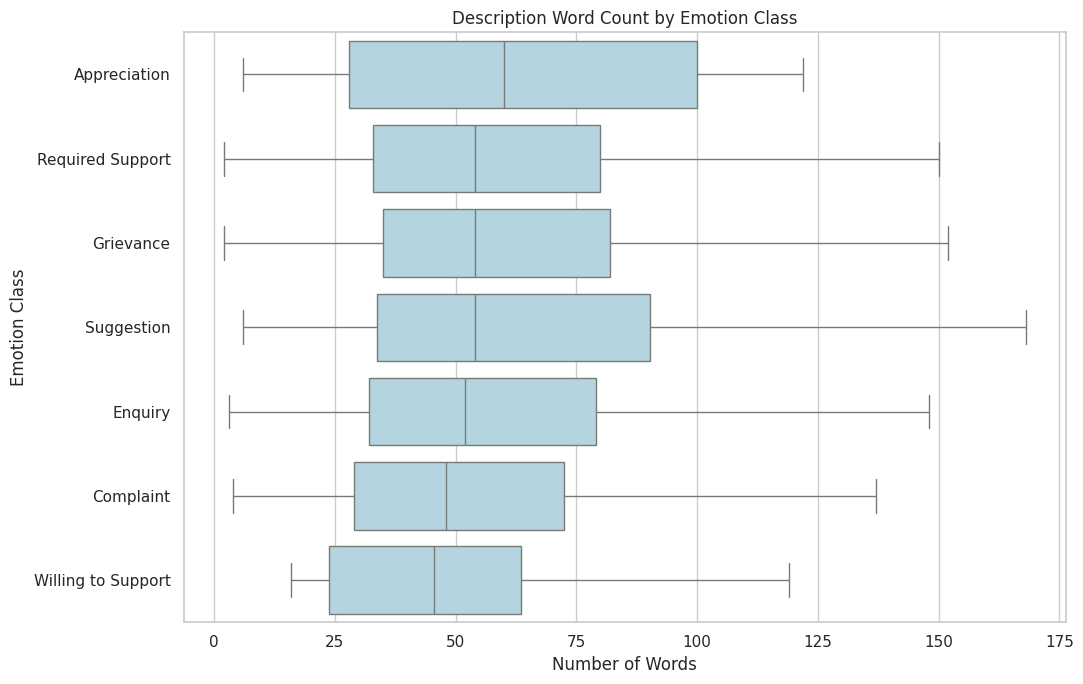

In [19]:
emotion_order = (
    df.groupby("Type")["Word Count"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df,
    x="Word Count",
    y="Type",
    order=emotion_order,
    color="lightblue",
    showfliers=False
)

plt.title("Description Word Count by Emotion Class")
plt.xlabel("Number of Words")
plt.ylabel("Emotion Class")
plt.tight_layout()
plt.show()

Appreciation has the highest median word count and Willing to Support has the lowest. The word-count distributions overlap across the 7 classes. So, description length alone isn't that sufficient for predicting the emotion class. The model will need to learn patterns from the actual words and phrases in each description.

## 6. Representative Text Samples

We show 2 randomly selected descriptions from each emotion class. 

In [20]:
representative_samples = (
    df.groupby("Type", group_keys=False)
    .sample(n=2, random_state=42)
    [["Type", "Nature", "Description", "Word Count"]]
    .sort_values("Type")
    .reset_index(drop=True)
)

display(representative_samples)

,Type,Nature,Description,Word Count
0,Appreciation,Other,"Gentle Reminder: Ref.: Your File No. Northern/1-12345678908/2022/EOA, dated 03.07.2022 for session 2022-23 Dear Sir, We would like to bring to yo...",122
1,Appreciation,Faculty record related,"RESPECTED SIR, i WISH TO INFORM YOU THAT, i COULD NOT ASSOCIATE MY FACULTY ID IN J P. COLLEGE OF ENGINEERING. for you kind reference i mentioned t...",60
2,Complaint,Payment/TER Charges related Query,mod of payment is highlight but bank name not show.,10
3,Complaint,Other,"Dear sir/Mam My name is Dr Shankar from Sri Nandhanam College of Engineering and Technology, Vellore dist, Tiruapttur, 635602. Our college permane...",51
4,Enquiry,Faculty related Query,Dear Sir It is to inform you that the faculty with PAN No. AAAAA0000A is working with this Institute. The institute in which he was working was cl...,54
5,Enquiry,Other,Existing Bank Account Details on the AICTE Portal are of Society and being shown as Institute Account. We want to show existing account details as...,129
6,Grievance,others,"Institute PID: 1-12345678900 with related to the approval process and EoA, we here by like to inform you that, in questionnaire tab all other tabs...",42
7,Grievance,DSC Registration Issue,"Sir, This is to inform you that we have started a New Government Polytechnic, Harohalli for the academic year 2022-23. In DSC utility tab we have ...",63
8,Required Support,Issue in Downloading of EoA,"We filled the Students details, Placement details and CII data. Print EOA is not showed in the report icon empty. please enable the icon to get pr...",27
9,Required Support,Other,"Respected Sir/ Madam, As per your Reminder email received, to fill the data about Passed out students for 2020-2021, we are trying to fill it. How...",111


The examples have administrative language and specific terms related to technical education and the AICTE portal. Some classes has similar wording, like requests for help, error reports, and descriptions of portal problems. The language and terminology are also specific to Indian technical institutions, which may limit how well a trained model generalizes to other countries or organizations.

## 7. Relationship Between Nature and Emotion Class

It will be a heatmap that examines whether particular issue categories are associated with specific emotion classes. The percentages are calculated with each Nature category.

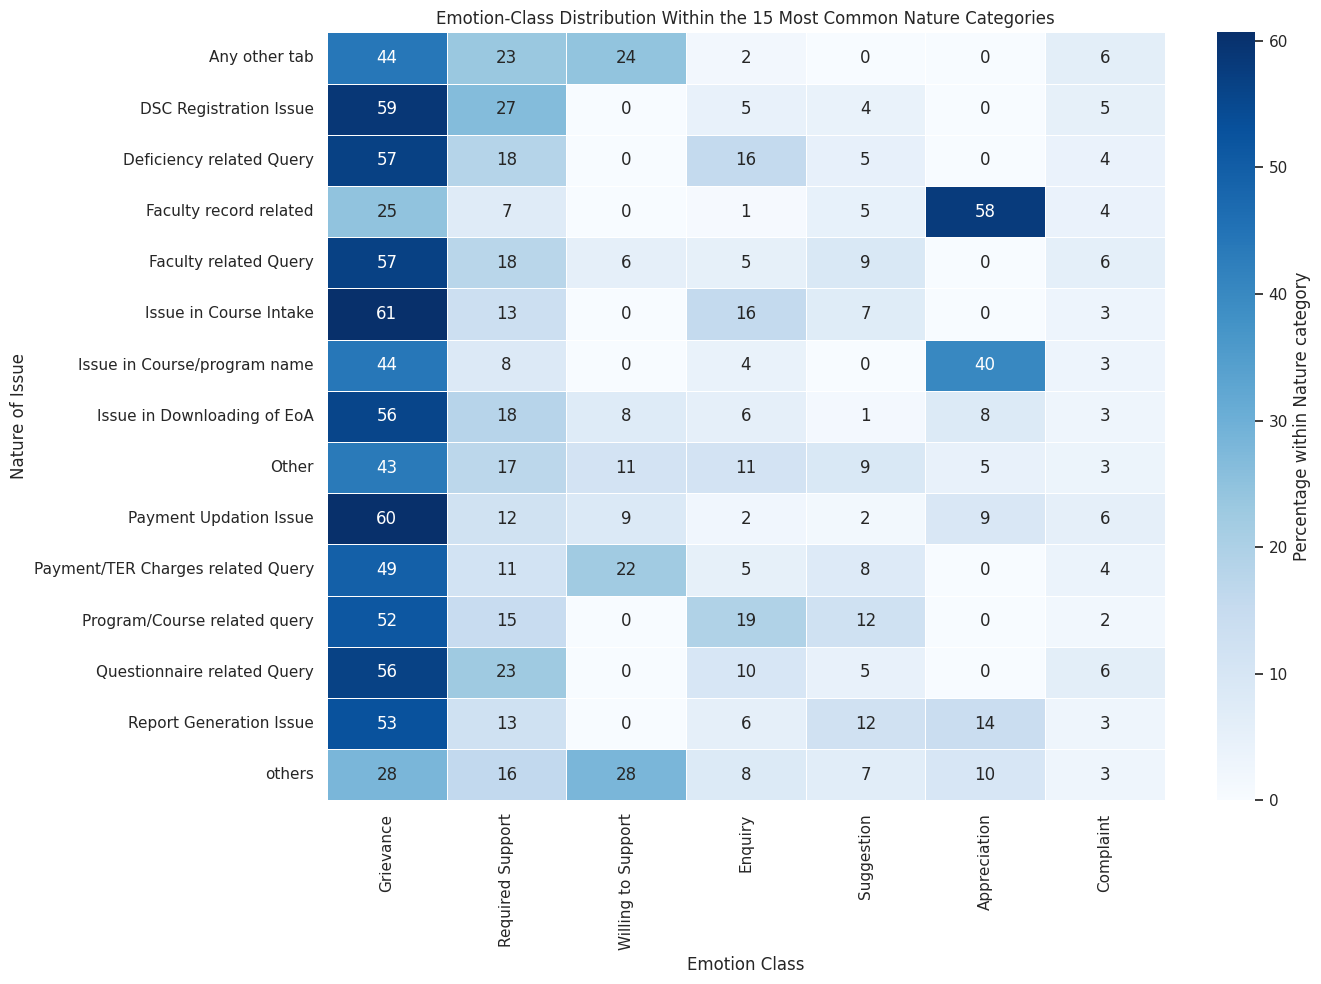

In [21]:
top_natures = df["Nature"].value_counts().head(15).index

heatmap_df = df[df["Nature"].isin(top_natures)]

nature_emotion_percent = pd.crosstab(
    heatmap_df["Nature"],
    heatmap_df["Type"],
    normalize="index"
) * 100

nature_emotion_percent = nature_emotion_percent[
    class_summary["Emotion"].tolist()
]

plt.figure(figsize=(14, 10))

sns.heatmap(
    nature_emotion_percent,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Percentage within Nature category"}
)

plt.title("Emotion-Class Distribution Within the 15 Most Common Nature Categories")
plt.xlabel("Emotion Class")
plt.ylabel("Nature of Issue")
plt.tight_layout()
plt.show()

Grievance is the class across most Nature categories, showing the overall class imbalance. 58% of Faculty record related submissions are labeled Appreciation, 40% of Issue in Course/program name submissions are labeled Appreciation. Each Nature category has several emotion classes, Nature alone can't determine the correct label. The separate categories Other and others also reveal inconsistent category like a possible data artifact.

## 8. Data Artifacts and Potential Failure Modes

We see possible issues that can affect model training or produce misleading evaluation results.

In [22]:
original_columns = [
    "Module Scheme Name",
    "Nature",
    "Description",
    "Character Count",
    "Type"
]

conflicting_descriptions = (
    df.groupby("Description")["Type"]
    .nunique()
    .gt(1)
    .sum()
)

artifact_summary = pd.DataFrame({
    "Potential issue": [
        "Exact duplicate observations",
        "Repeated descriptions beyond the first occurrence",
        "Descriptions containing 5 words or fewer",
        "Descriptions containing at least 990 characters",
        "Descriptions assigned to more than one emotion class"
    ],
    "Number of observations or groups": [
        df.duplicated(subset=original_columns).sum(),
        df.duplicated(subset=["Description"]).sum(),
        (df["Word Count"] <= 5).sum(),
        (df["Character Count"] >= 990).sum(),
        conflicting_descriptions
    ]
})

display(artifact_summary)

,Potential issue,Number of observations or groups
0,Exact duplicate observations,3564
1,Repeated descriptions beyond the first occurrence,3602
2,Descriptions containing 5 words or fewer,63
3,Descriptions containing at least 990 characters,159
4,Descriptions assigned to more than one emotion class,12


- **Duplicate observations:** The dataset contains 3,564 exact duplicate observations and 3,602 repeated descriptions. If identical descriptions show up the training and test sets, the model could memorize them and produce an optimistic test score. Duplicate descriptions should be removed or kept in the same data split before model training.
- **Very short descriptions:** 63 descriptions contain 5 words or less. These observations do not really provide enough information for model to identify the correct class.
- **Possible character limit:** 159 descriptions containing at least 990 characters. The submission system had a limit of arounf 1,000-character and may have truncated longer messages.
- **Potential label ambiguity:** 12 descriptions are associated with more than one emotion class. It might represent annotation inconsistencies or descriptions whose meanings fit multiple categories.
- **Class imbalance:** Grievance is 48.4% of the dataset and Complaint is only 4.1%. A model may therefore favor the majority class.
- **Geographic and institutional bias:** The data comes from Indian technical institutions and includes AICTE-specific terminology and formal language. A model trained on this dataset cannot generalize well to messages from other countries, institutions, or communication styles.
- **Category inconsistency:** Nature values like Other and others are stored separately, showing inconsistency in category naming.

## 9. Conclusions

The cleaned dataset has 14,133 observations across seven emotion classes. However, the target classes are imbalanced, with Grievance representing almost half of the data. Descriptions contain a median of 53 words, which provides enough text for a neural classifier. Very short submissions may be difficult to classify.

The overlap in description lengths and issue categories shows that features like text length or Nature cannot fully determine the emotion class. The model should learn patterns from the actual words and phrases in each description. 
A text CNN is a feasible initial approach because it can learn local phrase patterns. Before training, duplicate descriptions should be removed or grouped into the same split to avoid data leakage. Model evaluation should include macro F1 and per-class precision and recall in addition to accuracy because of the imbalance.